In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')
fao_meat = pd.read_csv('../data/raw/FAOSTAT_meat_prod_2024.csv')


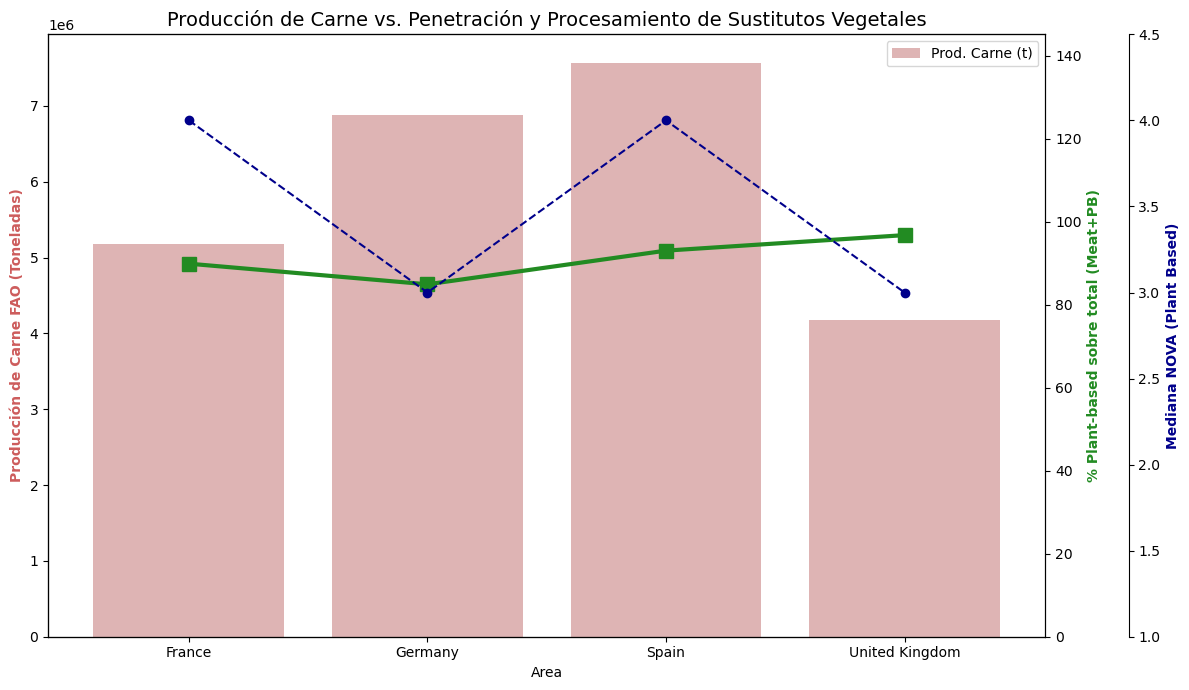

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir países y palabras clave (incluyendo francés/español por si acaso)
paises = ['France', 'Spain', 'United Kingdom', 'Germany']
meat_keywords = 'meat|carne|viande|beef|pork|chicken|poultry'
pb_keywords = 'plant-based|vegetal|vegan|vegetarian|végétal'

# 2. Etiquetar productos en el dataset foods
# Usamos .str.contains con regex para ser más flexibles
is_meat = foods['categories'].str.contains(meat_keywords, case=False, na=False)
is_pb = foods['categories'].str.contains(pb_keywords, case=False, na=False)

# 3. Crear subset y asignar tipos
subset = foods[foods['main_country'].isin(paises)].copy()
subset['type'] = 'other'
subset.loc[is_meat, 'type'] = 'meat'
subset.loc[is_pb, 'type'] = 'plant_based'

# 4. Agregación y APLANADO de columnas (Esto evita el KeyError)
stats = subset[subset['type'] != 'other'].groupby(['main_country', 'type']).agg(
    count=('code', 'count'),
    nova_median=('nova_group', 'median')
).unstack(fill_value=0) # fill_value=0 asegura que si un país no tiene una categoría, ponga 0 en vez de NaN

# Aplanamos el MultiIndex: ('count', 'meat') -> 'count_meat'
stats.columns = [f"{col[0]}_{col[1]}" for col in stats.columns]
stats = stats.reset_index()

# 5. Cálculos de métricas relativas
# Si 'count_plant_based' no existe porque no hubo ningún producto en todo el dataset, la creamos
if 'count_plant_based' not in stats.columns:
    stats['count_plant_based'] = 0
if 'nova_median_plant_based' not in stats.columns:
    stats['nova_median_plant_based'] = 0

stats['total_meat_pb'] = stats['count_meat'] + stats['count_plant_based']
stats['pct_plant_based'] = (stats['count_plant_based'] / stats['total_meat_pb'] * 100).fillna(0)

# 6. Unir con FAO
fao_meat_total = fao_meat[(fao_meat['Area'].isin(paises)) & (fao_meat['Item'] == 'Meat, Total')]
df_final = pd.merge(fao_meat_total, stats, left_on='Area', right_on='main_country')

# --- Gráfico ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# Barras: Producción de Carne (FAO)
sns.barplot(x='Area', y='Value', data=df_final, ax=ax1, color='indianred', alpha=0.5, label='Prod. Carne (t)')
ax1.set_ylabel('Producción de Carne FAO (Toneladas)', fontweight='bold', color='indianred')

# Eje 2: % Plant-based
ax2 = ax1.twinx()
ax2.plot(df_final['Area'], df_final['pct_plant_based'], color='forestgreen', marker='s', 
         markersize=10, linewidth=3, label='% Alternativas Vegetales')
ax2.set_ylabel('% Plant-based sobre total (Meat+PB)', fontweight='bold', color='forestgreen')
ax2.set_ylim(0, max(df_final['pct_plant_based']) * 1.5)

# Eje 3: Mediana NOVA
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(df_final['Area'], df_final['nova_median_plant_based'], color='darkblue', 
         marker='o', linestyle='--', label='Mediana NOVA PB')
ax3.set_ylabel('Mediana NOVA (Plant Based)', fontweight='bold', color='darkblue')
ax3.set_ylim(1, 4.5)

plt.title('Producción de Carne vs. Penetración y Procesamiento de Sustitutos Vegetales', fontsize=14)
fig.tight_layout()
plt.show()

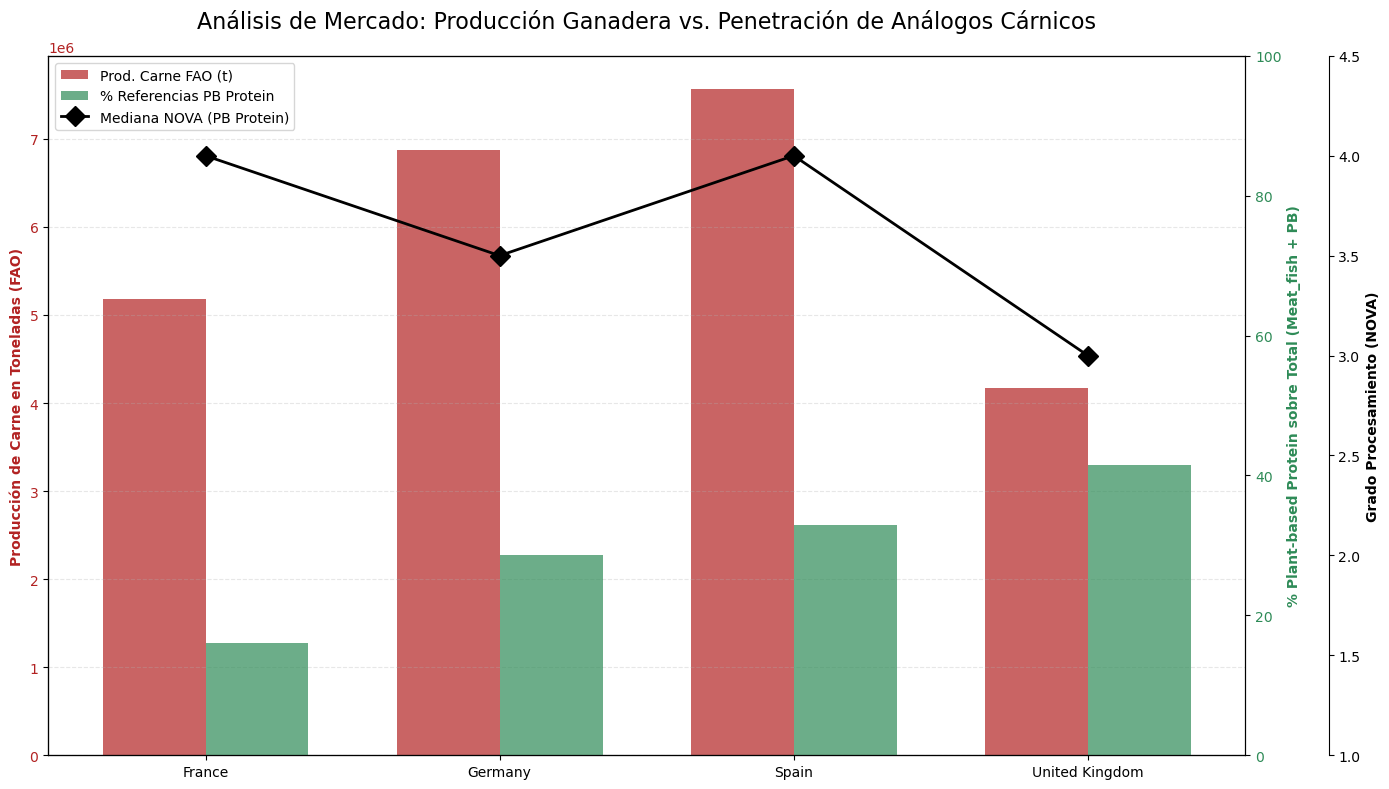

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuración de países y categorías exactas
paises = ['France', 'Spain', 'United Kingdom', 'Germany']

# 2. Filtrado directo por categorías
# Filtramos el dataset para quedarnos solo con lo que nos interesa
mask = (foods['main_country'].isin(paises)) & (foods['category_unified'].isin(['meat_fish', 'plant_based_protein']))
subset = foods[mask].copy()

# 3. Agregación de datos
# Agrupamos por país y categoría para obtener el conteo y la mediana de NOVA
stats = subset.groupby(['main_country', 'category_unified']).agg(
    count=('code', 'count'),
    nova_median=('nova_group', 'median')
).unstack(fill_value=0)

# Aplanamos las columnas del MultiIndex para trabajar cómodamente
stats.columns = [f"{col[1]}_{col[0]}" for col in stats.columns]
stats = stats.reset_index()

# 4. Cálculo del porcentaje relativo
# % = (Proteína Vegetal / (Carne y Pescado + Proteína Vegetal)) * 100
stats['total_comparativa'] = stats['meat_fish_count'] + stats['plant_based_protein_count']
stats['pct_pb_protein'] = (stats['plant_based_protein_count'] / stats['total_comparativa'] * 100).fillna(0)

# 5. Unión con los datos de producción de la FAO
fao_filtered = fao_meat[(fao_meat['Area'].isin(paises)) & (fao_meat['Item'] == 'Meat, Total')]
df_final = pd.merge(fao_filtered, stats, left_on='Area', right_on='main_country')

# --- VISUALIZACIÓN ---
fig, ax1 = plt.subplots(figsize=(14, 8))
x = np.arange(len(df_final['Area']))
width = 0.35

# Barra 1: Producción de Carne Real (FAO) - Eje Izquierdo
ax1.bar(x - width/2, df_final['Value'], width, label='Prod. Carne FAO (t)', color='#b22222', alpha=0.7)
ax1.set_ylabel('Producción de Carne en Toneladas (FAO)', fontweight='bold', color='#b22222')
ax1.tick_params(axis='y', labelcolor='#b22222')

# Barra 2: % Cuota de Análogos (PB Protein) - Eje Derecho
ax2 = ax1.twinx()
ax2.bar(x + width/2, df_final['pct_pb_protein'], width, label='% Referencias PB Protein', color='#2e8b57', alpha=0.7)
ax2.set_ylabel('% Plant-based Protein sobre Total (Meat_fish + PB)', fontweight='bold', color='#2e8b57')
ax2.tick_params(axis='y', labelcolor='#2e8b57')
ax2.set_ylim(0, 100) # Escala porcentual real

# Línea: Mediana NOVA de la categoría plant_based_protein
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60)) # Movemos el tercer eje a la derecha
ax3.plot(df_final['Area'], df_final['plant_based_protein_nova_median'], 
         color='black', marker='D', markersize=10, linewidth=2, label='Mediana NOVA (PB Protein)')
ax3.set_ylabel('Grado Procesamiento (NOVA)', fontweight='bold', color='black')
ax3.set_ylim(1, 4.5)

# Estética y Leyendas
plt.title('Análisis de Mercado: Producción Ganadera vs. Penetración de Análogos Cárnicos', fontsize=16, pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(df_final['Area'])

# Combinamos las leyendas de los 3 ejes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines + lines2 + lines3, labels + labels2 + labels3, loc='upper left')

ax1.grid(axis='y', linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()

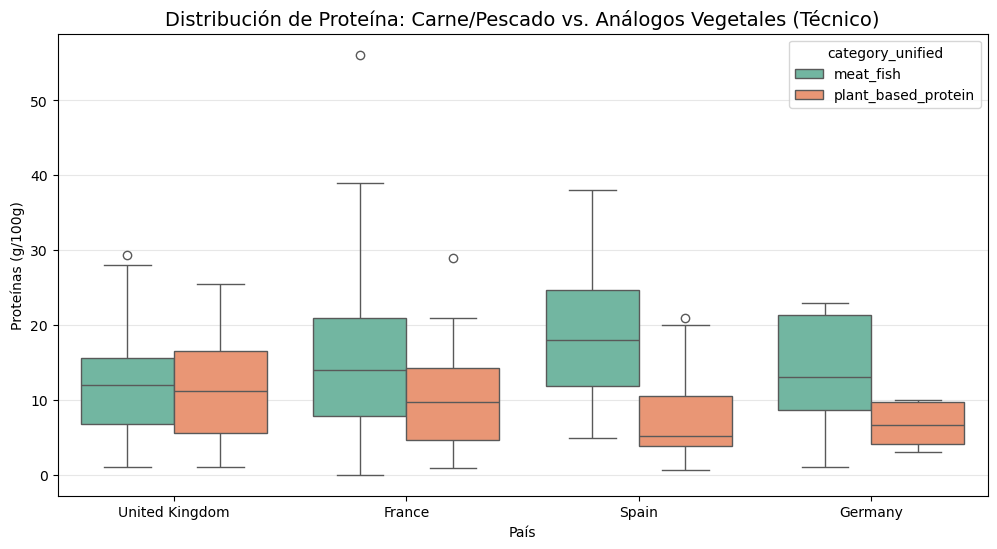

/tmp/ipykernel_6012/1774259392.py:27: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(data=df_protein, x='main_country', y='proteins_100g', hue='category_unified',


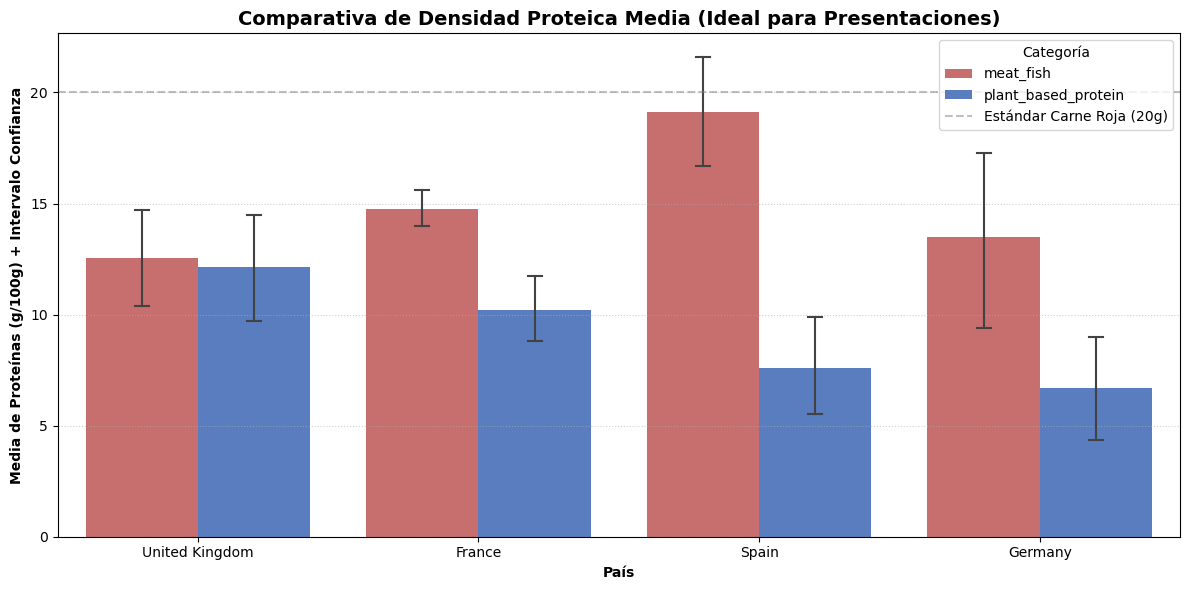

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuración de datos
paises = ['France', 'Spain', 'United Kingdom', 'Germany']
categorias = ['meat_fish', 'plant_based_protein']

# Filtrar el dataset original
df_protein = foods[(foods['main_country'].isin(paises)) & 
                   (foods['category_unified'].isin(categorias))].copy()

# --- GRÁFICO 1: EL BOXPLOT (ANÁLISIS TÉCNICO) ---
# Útil para ver valores atípicos y la dispersión total
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_protein, x='main_country', y='proteins_100g', hue='category_unified', palette='Set2')
plt.title('Distribución de Proteína: Carne/Pescado vs. Análogos Vegetales (Técnico)', fontsize=14)
plt.ylabel('Proteínas (g/100g)')
plt.xlabel('País')
plt.grid(axis='y', alpha=0.3)
plt.savefig('boxplot_proteina.png')
plt.show()

# --- GRÁFICO 2: EL GRÁFICO DE BARRAS (PRESENTACIÓN EJECUTIVA) ---
# Mucho más limpio. Muestra la media y el intervalo de confianza (error bars)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_protein, x='main_country', y='proteins_100g', hue='category_unified', 
            palette=['#d65f5f', '#4878d0'], capsize=.1, errwidth=1.5)

plt.title('Comparativa de Densidad Proteica Media (Ideal para Presentaciones)', fontsize=14, fontweight='bold')
plt.ylabel('Media de Proteínas (g/100g) + Intervalo Confianza', fontweight='bold')
plt.xlabel('País', fontweight='bold')

# Añadir una línea horizontal de referencia (ejemplo: 20g/100g es el estándar de un filete)
plt.axhline(20, color='grey', linestyle='--', alpha=0.5, label='Estándar Carne Roja (20g)')

plt.legend(title='Categoría')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('barras_proteina_presentacion.png')
plt.show()